 Job Skills Schema 
+--------------------+--------------------+
|            job_link|          job_skills|
+--------------------+--------------------+
|https://www.linke...|Building Custodia...|
|https://www.linke...|Customer service,...|
|https://www.linke...|Applied Behavior ...|
|https://www.linke...|Electrical Engine...|
|https://www.linke...|Electrical Assemb...|
+--------------------+--------------------+
only showing top 5 rows

 LinkedIn Job Postings Schema 
+--------------------+--------------------+-----------+-------+---------------+--------------------+--------------------+--------------------+----------+-----------+--------------+--------------------+----------+--------+
|            job_link| last_processed_time|got_summary|got_ner|is_being_worked|           job_title|             company|        job_location|first_seen|search_city|search_country|     search_position| job_level|job_type|
+--------------------+--------------------+-----------+-------+---------------+-----

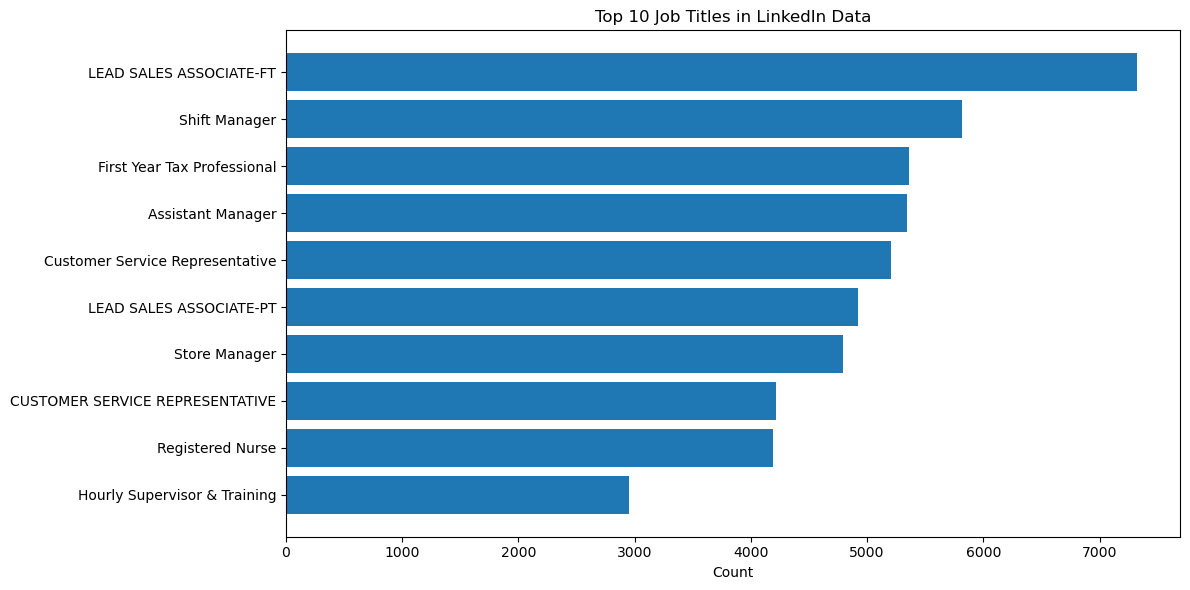

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder \
    .appName("EDA Datasets") \
    .getOrCreate()

#HDFS Path
hdfs_path = "hdfs://namenode:8020/user/hadoop/csv_datasets/"

#Read CSV Files
job_skills_df = spark.read.option("header", True).csv(hdfs_path + "job_skills.csv")
linkedin_jobs_df = spark.read.option("header", True).csv(hdfs_path + "linkedin_job_postings.csv")
job_summary_df = spark.read.option("header", True).csv(hdfs_path + "job_summary.csv")

print(" Job Skills Schema ")
job_skills_df.show(5)

print(" LinkedIn Job Postings Schema ")
linkedin_jobs_df.show(5)

print(" Job Summary Schema ")
job_summary_df.show(5)

print(" Job Skills describe ")
job_skills_df.describe().show()

print(" LinkedIn Job Postings describe ")
linkedin_jobs_df.describe().show()

print(" Job Summary describe ")
job_summary_df.describe().show()

print(" Job Skills summary ")
job_skills_df.summary().show()

print(" LinkedIn Job Postings summary ")
linkedin_jobs_df.summary().show()

print(" Job Summary summary ")
job_summary_df.summary().show()

jobTitles = linkedin_jobs_df.groupBy("job_title").count().orderBy("count", ascending=False).limit(10)

jobTitles_pd = jobTitles.toPandas()

plt.figure(figsize=(12,6))
plt.barh(jobTitles_pd['job_title'], jobTitles_pd['count'])
plt.xlabel('Count')
plt.title('Top 10 Job Titles in LinkedIn Data')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


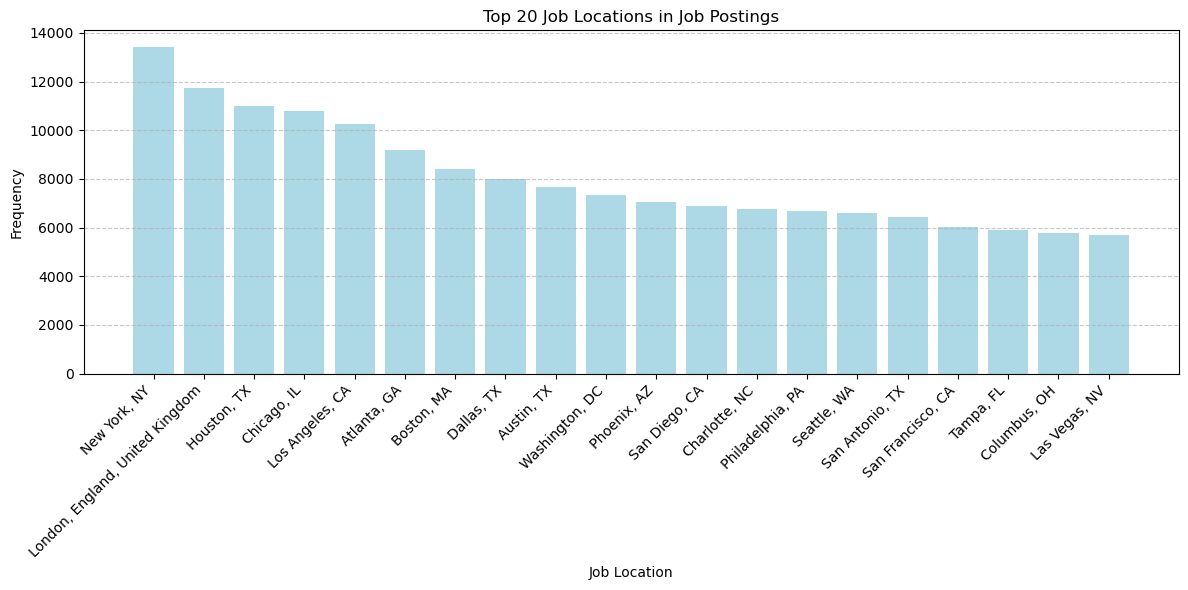

In [ ]:
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

#Group by job_location and count by dropping nulls
location_counts = linkedin_jobs_df.where(col("job_location").isNotNull()) \
    .groupBy("job_location").count().orderBy("count", ascending=False)

#Take top 20 and convert to Pandas
location_counts_pd = location_counts.limit(20).toPandas()

# Plot
plt.figure(figsize=(12,6))
plt.bar(location_counts_pd['job_location'], location_counts_pd['count'], color='lightblue')

plt.xlabel("Job Location")
plt.ylabel("Frequency")
plt.title("Top 20 Job Locations in Job Postings")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


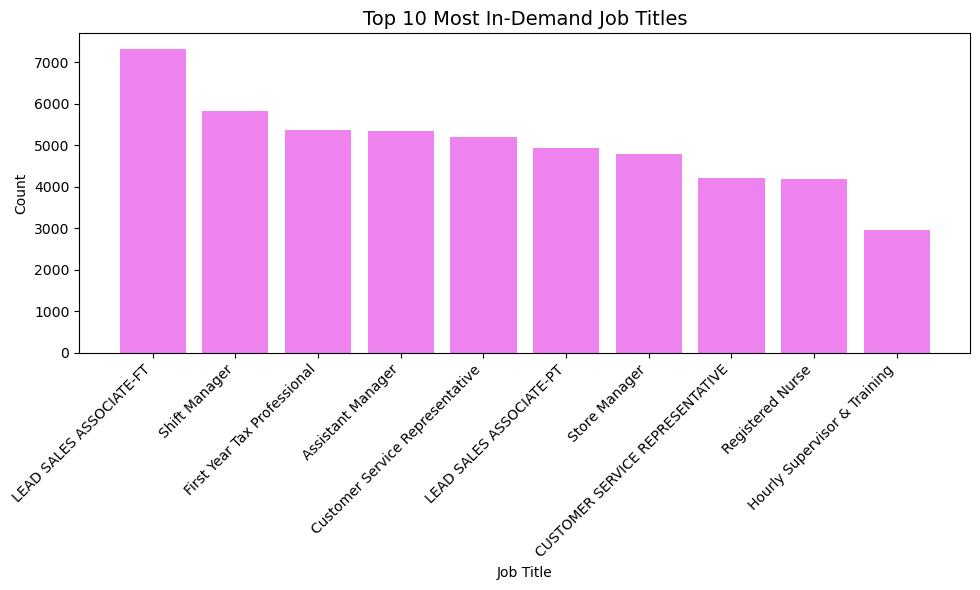

In [4]:
#Plot  of Top 10 Most In-Demand Job Titles
import matplotlib.pyplot as plt

# Group job titles
topJobTitles = linkedin_jobs_df.groupBy("job_title").count().orderBy("count", ascending=False).limit(10)

# Convert to Pandas
topJobTitlesPd = topJobTitles.toPandas()

plt.figure(figsize=(10,6))
plt.bar(topJobTitlesPd['job_title'], topJobTitlesPd['count'], color='violet')

plt.title('Top 10 Most In-Demand Job Titles', fontsize=14)
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


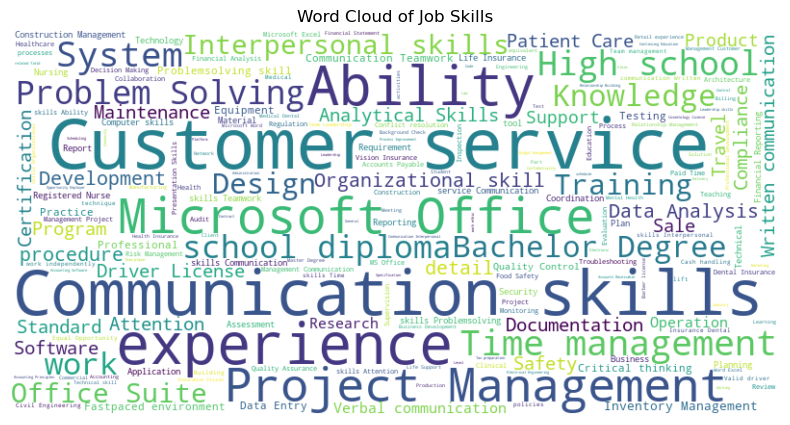

In [3]:
from pyspark.sql.functions import col
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#Filter non-null
job_skills_clean = job_skills_df.filter(col('job_skills').isNotNull())

# Take only 10,000 skills
skills_list = job_skills_clean.limit(10000).select('job_skills').rdd.flatMap(lambda x: x).collect()

#Join all skills into a single string
text = " ".join(skills_list)

#Generate Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Job Skills")
plt.show()


In [2]:
pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 MB 7.9 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 4.7 MB/s eta 0:00:00a 0:00:01
  Created wheel for pyspark: filename=pyspark-3.5.5-py2.py3-none-any.whl size=317747860 sha256=d94a1cd21bd3a3975abe47a35492183de3def24354ff5f0071c715197d741cac
  Stored in directory: /home/jovyan/.cache/pip/wheels/0c/7f/b4/0e68c6d8d89d2e582e5498ad88616c16d7c19028680e9d3840
Successfully built pyspark
Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install WordCloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.9/547.9 kB 3.8 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
spark.stop()